# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Juan Sebastian Diaz Campos, 2026

# 04_modelo

En esta plantilla entregada por el profesor Diego Fernando Marin se llevará a cabo el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno representa la culminación del proceso, donde aplicamos técnicas de machine learning para crear modelos predictivos o descriptivos basados en los datos preparados.

**Propósito:** Desarrollar, entrenar y validar modelos de machine learning que respondan a los objetivos del proyecto.

**Tareas habituales:**
- Selección de características (feature selection)
- Ingeniería de características (feature engineering)
- División de datos en conjuntos de entrenamiento y prueba
- Selección y entrenamiento de modelos
- Optimización de hiperparámetros
- Validación cruzada
- Evaluación de métricas de rendimiento
- Documentación del proceso de modelado
- Guardado y versionado de modelos
- Análisis de importancia de características

In [23]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
cwd = os.getcwd() # current working directory
trusted_dir = cwd + '/../data/trusted/'
surface_dir = cwd + '/../data/surface/'

In [4]:
df = pd.read_csv(trusted_dir + 'datos_limpios_ml.csv', parse_dates=["Fecha_apertura", "Fecha_cierre"])

## Diseñar el Modelo

In [17]:
serie = (df.groupby(pd.Grouper(key="Fecha_apertura",freq="D")).size().reset_index(name="Solicitudes"))
serie.rename(columns={"Fecha_apertura":"ds","Solicitudes":"y"},inplace=True)

In [18]:
serie["dia_semana"] = serie["ds"].dt.dayofweek
serie["mes"] = serie["ds"].dt.month
serie["es_habil"] = serie["dia_semana"] < 5
serie["es_habil"] = serie["es_habil"].astype(int)
serie.head()

,ds,y,dia_semana,mes,es_habil
0,2024-05-06,2,0,5,1
1,2024-05-07,0,1,5,1
2,2024-05-08,5,2,5,1
3,2024-05-09,1,3,5,1
4,2024-05-10,6,4,5,1


In [20]:
tamaño_entrenamiento = int(len(serie)*0.80)
train = serie.iloc[:tamaño_entrenamiento]
test = serie.iloc[tamaño_entrenamiento:]

print(train.shape)
print(test.shape)

(628, 5)
(158, 5)


In [41]:
from prophet import Prophet
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

## Entrenar el Modelo

In [70]:
modelo = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.05,
    interval_width=0.95
)

In [56]:
modelo.fit(train)

19:47:42 - cmdstanpy - INFO - Chain [1] start processing
19:47:43 - cmdstanpy - INFO - Chain [1] done processing


In [57]:
future = test.copy()
forecast = modelo.predict(future)
forecast[["ds","yhat","yhat_lower","yhat_upper"]].head()

,ds,yhat,yhat_lower,yhat_upper
0,2026-01-24,2.175382,-7.587441,11.829664
1,2026-01-25,1.866047,-7.570812,12.378281
2,2026-01-26,11.826026,2.081471,21.449549
3,2026-01-27,12.741687,2.978366,22.199466
4,2026-01-28,12.286498,2.492828,22.135833


In [58]:
comparacion = pd.DataFrame({"Fecha":test["ds"],"Real":test["y"],"Prediccion":forecast["yhat"]})
comparacion.head()

,Fecha,Real,Prediccion
0,NaT,NaN,2.175382
1,NaT,NaN,1.866047
2,NaT,NaN,11.826026
3,NaT,NaN,12.741687
4,NaT,NaN,12.286498


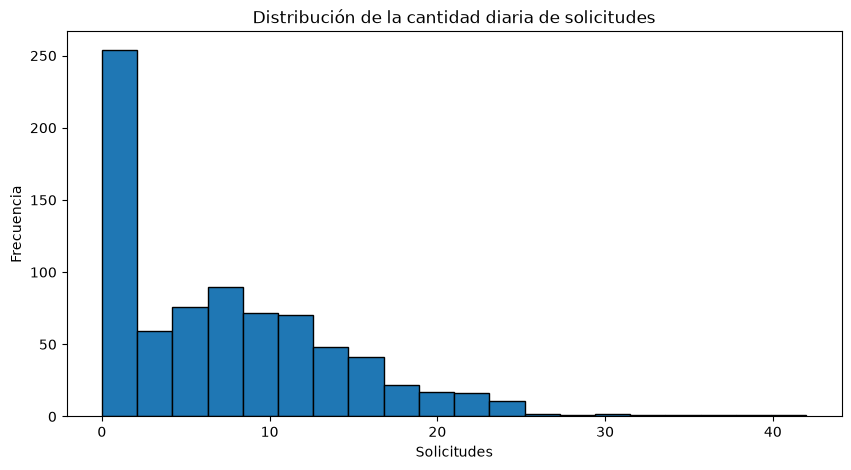

In [59]:
plt.figure(figsize=(10,5))

plt.hist(
    serie["y"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribución de la cantidad diaria de solicitudes")
plt.xlabel("Solicitudes")
plt.ylabel("Frecuencia")

plt.show()

In [60]:
serie["y"].describe()

count    786.000000
mean       7.477099
std        6.902422
min        0.000000
25%        1.000000
50%        7.000000
75%       12.000000
max       42.000000
Name: y, dtype: float64

## Verificar el Modelo - Hacer Pruebas

In [61]:
comparacion = test[["ds", "y"]].copy()
comparacion["Prediccion"] = forecast["yhat"].values
comparacion.head()

,ds,y,Prediccion
628,2026-01-24,0,2.175382
629,2026-01-25,0,1.866047
630,2026-01-26,4,11.826026
631,2026-01-27,11,12.741687
632,2026-01-28,8,12.286498


In [62]:
mae = mean_absolute_error(
    comparacion["y"],
    comparacion["Prediccion"]
)

rmse = np.sqrt(
    mean_squared_error(
        comparacion["y"],
        comparacion["Prediccion"]
    )
)

mape = mean_absolute_percentage_error(
    comparacion["y"],
    comparacion["Prediccion"]
) * 100

In [63]:
metricas = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "MAPE (%)"],
    "Valor": [
        round(mae,2),
        round(rmse,2),
        round(mape,2)
    ]
})

metricas

,Métrica,Valor
0,MAE,5.370000e+00
1,RMSE,6.560000e+00
2,MAPE (%),3.445814e+17


In [64]:
comparacion[comparacion["y"] == 0]

,ds,y,Prediccion
628,2026-01-24,0,2.175382
629,2026-01-25,0,1.866047
636,2026-02-01,0,2.244754
642,2026-02-07,0,2.828386
650,2026-02-15,0,2.967030
657,2026-02-22,0,3.386771
664,2026-03-01,0,2.790287
671,2026-03-08,0,0.787067
677,2026-03-14,0,-1.107047
678,2026-03-15,0,-1.906912


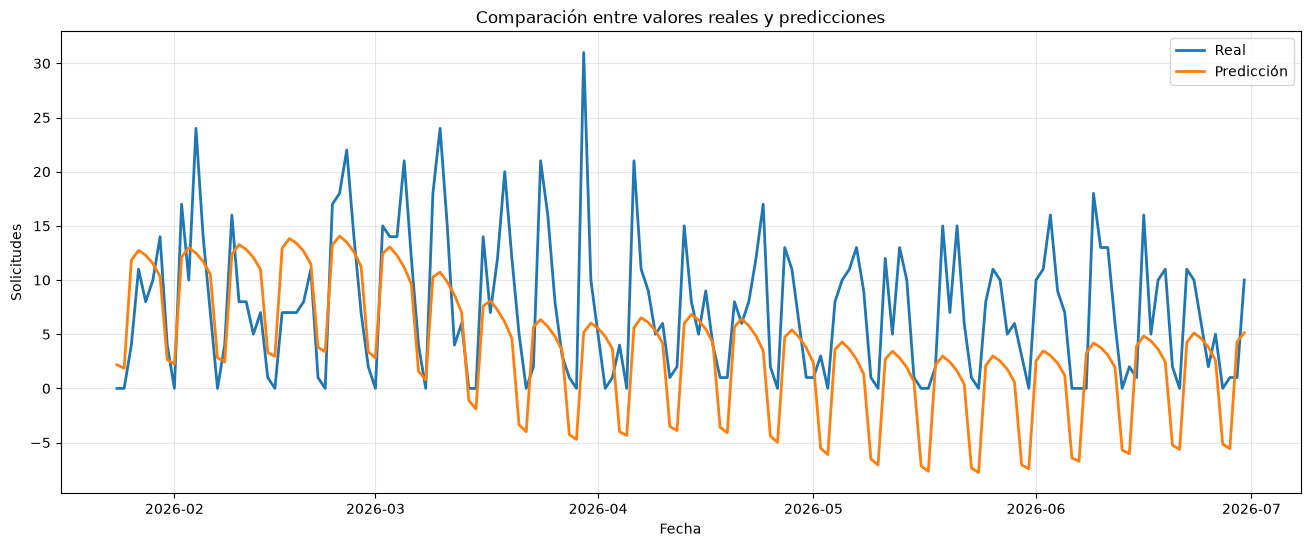

In [65]:
plt.figure(figsize=(16,6))

plt.plot(
    comparacion["ds"],
    comparacion["y"],
    label="Real",
    linewidth=2
)

plt.plot(
    comparacion["ds"],
    comparacion["Prediccion"],
    label="Predicción",
    linewidth=2
)

plt.title("Comparación entre valores reales y predicciones")

plt.xlabel("Fecha")

plt.ylabel("Solicitudes")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

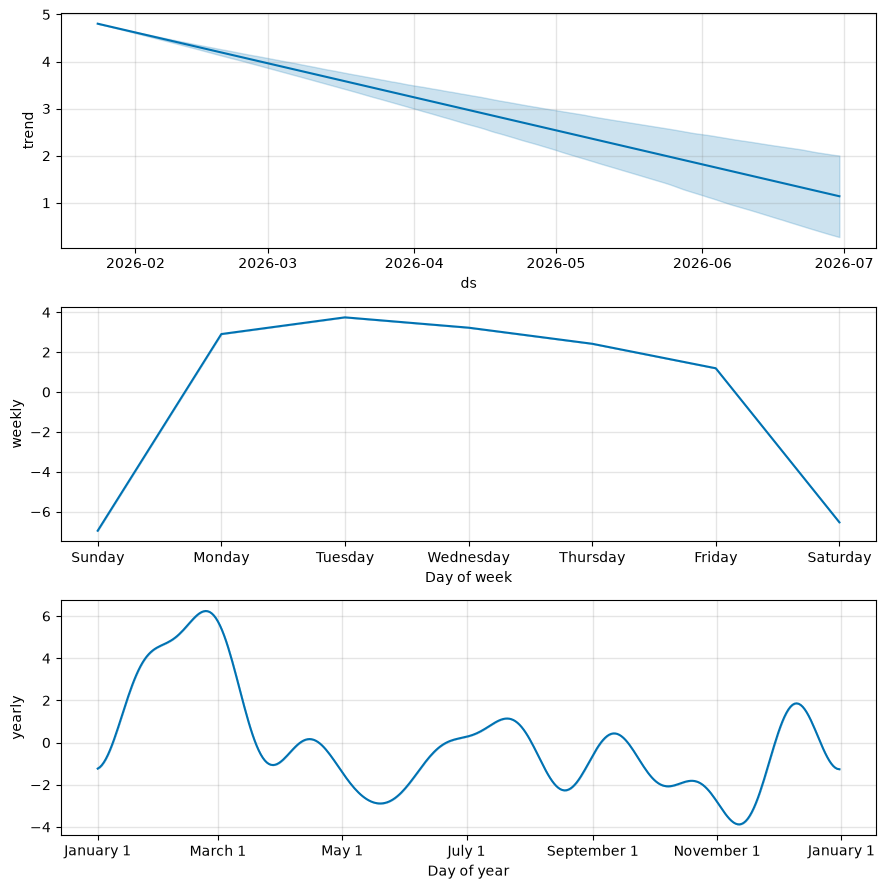

In [66]:
modelo.plot_components(forecast)

plt.show()

In [67]:
future = modelo.make_future_dataframe(
    periods=30,
    freq="D"
)

In [68]:
future["dia_semana"] = future["ds"].dt.dayofweek
future["es_habil"] = (future["dia_semana"] < 5).astype(int)
forecast_futuro = modelo.predict(future)

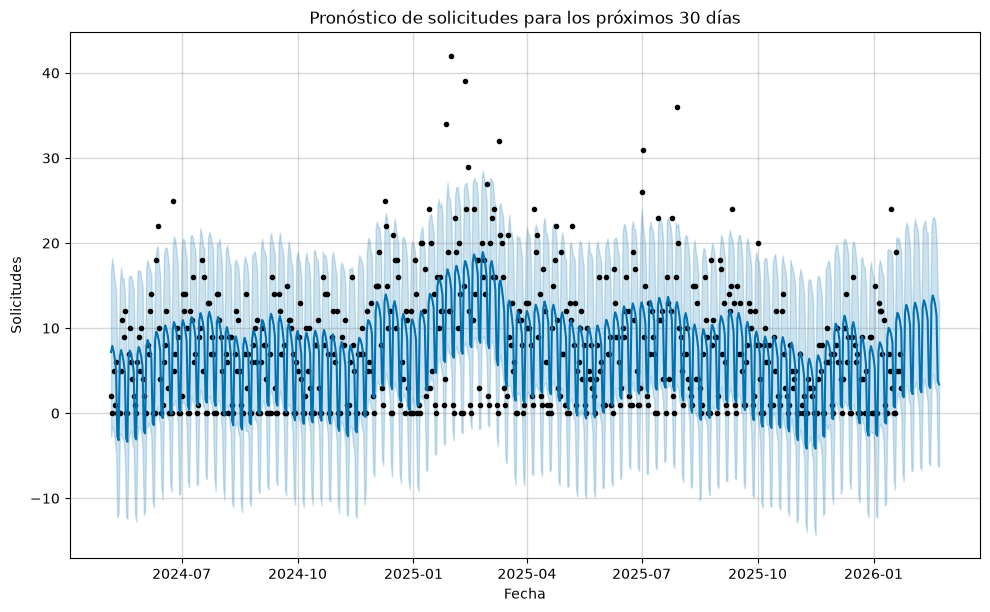

In [69]:
fig = modelo.plot(forecast_futuro)

plt.title("Pronóstico de solicitudes para los próximos 30 días")

plt.xlabel("Fecha")

plt.ylabel("Solicitudes")

plt.grid(alpha=0.3)

plt.show()

In [71]:
pronostico_30 = forecast_futuro.tail(30)

pronostico_30[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]

,ds,yhat,yhat_lower,yhat_upper
628,2026-01-24,2.175382,-7.153844,11.101917
629,2026-01-25,1.866047,-7.947530,10.988574
630,2026-01-26,11.826026,1.963401,21.272440
631,2026-01-27,12.741687,3.337952,22.369387
632,2026-01-28,12.286498,3.209897,22.067315
633,2026-01-29,11.529088,1.471439,20.866836
634,2026-01-30,10.338512,0.998969,19.437254
635,2026-01-31,2.642229,-6.683774,12.284610
636,2026-02-01,2.244754,-6.802749,11.456120
637,2026-02-02,12.131898,3.081411,21.679024


In [72]:
serie.tail()

,ds,y,dia_semana,mes,es_habil
781,2026-06-26,5,4,6,1
782,2026-06-27,0,5,6,0
783,2026-06-28,1,6,6,0
784,2026-06-29,1,0,6,1
785,2026-06-30,10,1,6,1


**Último paso**: Guardar el Modelo para ser utilizado en el **Producto de Datos**

**Producto de Datos**:

- Aplicación Web, formulario que pide los datos y entrega la estimación/predicción/etc.
- Aplicación Móvil
- Tablero o _Dashboard_: Dash, Streamlit, Flask, PowerBI, Tableau, Qlik, Looker
- API: permite hacer las consultas para "embeberlas" en una aplicación de usuario
